# Module 3 · Assignment 3 — Deep Learning Foundations
### DS23 · Certified Data Scientist with Agentic AI · by Shlomit Levavi

**This is a guided starter notebook, not a solution.** Fill every `# TODO`.
The model is the easy 30%. The interrogation in `REPORT.md` is the graded 70%.

Pick **one** option in Part 1. Write all code and comments in **English**.

**Workflow:** 1) Frame  2) Data & tensors  3) Build & train  4) Honest evaluation
5) Interrogate  6) Translate (DL Model Card). Framework: **PyTorch**.

> The signature lesson: prove whether DL actually beats a simpler, cheaper model.


---
## Part 0 · Frame (write in REPORT.md)
Same metric/baseline thinking. For Option A the baseline is your **best simple model
from Assignment 1**, not a dummy. State what "DL was worth it" would mean here.

## Part 1 · Setup & data

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
from torch.utils.data import DataLoader, TensorDataset

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import f1_score, roc_auc_score, classification_report

torch.manual_seed(42); np.random.seed(42)
DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
print("device:", DEVICE)

device: cpu


### Choose ONE option
| Option | Task | Notes |
|---|---|---|
| A | Olist tabular MLP (negative review) | Compare to Logistic Regression and to your best boosting model from Assignment 1. |
| B | Fashion-MNIST CNN | torchvision built-in. Where DL shines. |
| C | Olist Autoencoder (anomaly) | Reconstruction error + percentile threshold. |

In [3]:
# ---- Option B · Fashion-MNIST -------------------------------------------------
# from torchvision import datasets, transforms
# tfm = transforms.Compose([transforms.ToTensor(),
#                           transforms.Normalize((0.2860,), (0.3530,))])
# train_ds = datasets.FashionMNIST("data", train=True,  download=True, transform=tfm)
# test_ds  = datasets.FashionMNIST("data", train=False, download=True, transform=tfm)
# train_loader = DataLoader(train_ds, batch_size=64, shuffle=True)

from torchvision import datasets, transforms
from torch.utils.data import DataLoader, random_split

# Fashion-MNIST normalization values
transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.2860,), (0.3530,))
])

# Download the original training and test datasets
full_train_ds = datasets.FashionMNIST(
    root="data",
    train=True,
    download=True,
    transform=transform
)

test_ds = datasets.FashionMNIST(
    root="data",
    train=False,
    download=True,
    transform=transform
)

# Split the original training dataset into train and validation sets
train_size = int(0.8 * len(full_train_ds))
val_size = len(full_train_ds) - train_size

generator = torch.Generator().manual_seed(42)

train_ds, val_ds = random_split(
    full_train_ds,
    [train_size, val_size],
    generator=generator
)

# Create DataLoaders
BATCH_SIZE = 64

train_loader = DataLoader(
    train_ds,
    batch_size=BATCH_SIZE,
    shuffle=True
)

val_loader = DataLoader(
    val_ds,
    batch_size=BATCH_SIZE,
    shuffle=False
)

test_loader = DataLoader(
    test_ds,
    batch_size=BATCH_SIZE,
    shuffle=False
)

print("Training samples:", len(train_ds))
print("Validation samples:", len(val_ds))
print("Test samples:", len(test_ds))


100%|██████████| 26.4M/26.4M [00:02<00:00, 9.62MB/s]
100%|██████████| 29.5k/29.5k [00:00<00:00, 137kB/s]
100%|██████████| 4.42M/4.42M [00:01<00:00, 2.53MB/s]
100%|██████████| 5.15k/5.15k [00:00<00:00, 13.7MB/s]

Training samples: 48000
Validation samples: 12000
Test samples: 10000


In [4]:
images, labels = next(iter(train_loader))

print("Image batch shape:", images.shape)
print("Label batch shape:", labels.shape)
print("Image data type:", images.dtype)
print("Label data type:", labels.dtype)
print("Label examples:", labels[:10])

Image batch shape: torch.Size([64, 1, 28, 28])
Label batch shape: torch.Size([64])
Image data type: torch.float32
Label data type: torch.int64
Label examples: tensor([9, 8, 2, 6, 9, 0, 3, 5, 2, 1])


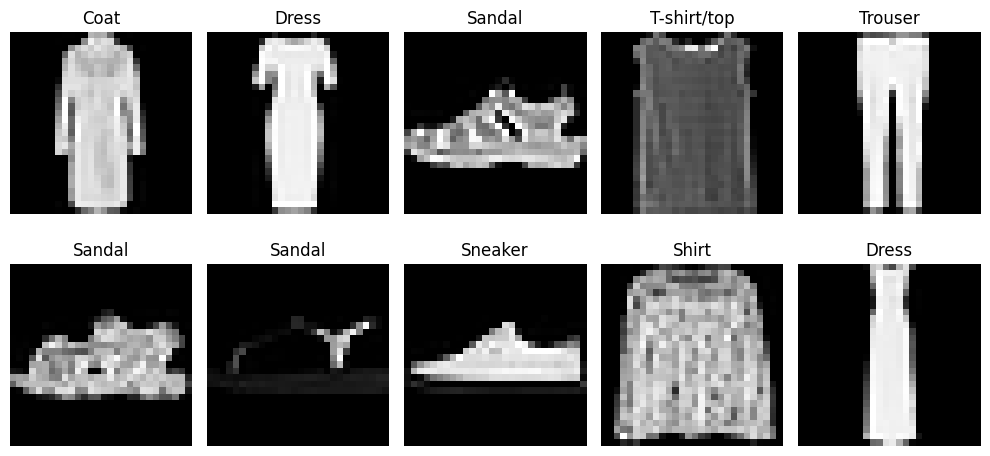

In [5]:
class_names = [
    "T-shirt/top",
    "Trouser",
    "Pullover",
    "Dress",
    "Coat",
    "Sandal",
    "Shirt",
    "Sneaker",
    "Bag",
    "Ankle boot"
]

images, labels = next(iter(train_loader))

plt.figure(figsize=(10, 5))

for i in range(10):
    plt.subplot(2, 5, i + 1)

    # Reverse the normalization for visualization
    image = images[i].squeeze().numpy()
    image = image * 0.3530 + 0.2860

    plt.imshow(image, cmap="gray")
    plt.title(class_names[labels[i].item()])
    plt.axis("off")

plt.tight_layout()
plt.show()

---
## Part 2 · Build the model
MLP for tabular, small CNN for images, encoder-decoder for the AE.
Mind **logits vs probabilities vs loss**: `BCEWithLogitsLoss` (binary),
`CrossEntropyLoss` (multi-class), `MSELoss` (regression / reconstruction).
Do NOT apply sigmoid/softmax before these losses.

In [6]:
class CNN(nn.Module):
    def __init__(self):
        super().__init__()
        # TODO: define layers. Output a single logit for binary classification.
        # self.net = nn.Sequential(nn.Linear(in_features, hidden), nn.ReLU(),
        #                          nn.Dropout(0.2), nn.Linear(hidden, 1))
        self.features = nn.Sequential(
            nn.Conv2d(in_channels=1, out_channels=16, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(kernel_size=2),
            nn.Conv2d(in_channels=16, out_channels=32, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(kernel_size=2)
        )
        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Linear(in_features=32*7*7, out_features=10)
        )

    def forward(self, x):
        # return self.net(x)   # raw logits, no sigmoid here
        return self.classifier(self.features(x))

loss_fn = nn.CrossEntropyLoss()   # expects logits, not probabilities


---
## Part 3 · Train
The standard loop: `model.train()`, then per batch `zero_grad -> forward -> loss
-> backward -> step`. Evaluate with `model.eval()` + `torch.no_grad()`.
Use Adam and at least one regularizer (dropout / early stopping).

In [7]:
def train_one_epoch(model, loader, loss_fn, optimizer):
    model.train()
    for xb, yb in loader:
        xb, yb = xb.to(DEVICE), yb.to(DEVICE)
        optimizer.zero_grad()
        logits = model(xb)
        loss = loss_fn(logits, yb)
        loss.backward()
        optimizer.step()

@torch.no_grad()
def evaluate(model, loader, loss_fn):
    model.eval()
    # TODO: accumulate loss and predictions, return metric(s).

    total_loss = 0
    correct = 0
    total = 0
    for xb, yb in loader:
        xb, yb = xb.to(DEVICE), yb.to(DEVICE)
        logits = model(xb)
        loss = loss_fn(logits, yb)
        total_loss += loss.item() * xb.size(0)
        preds = logits.argmax(dim=1)
        correct += (preds == yb).sum().item()
        total += yb.size(0)
    accuracy = correct/total
    avg_loss = total_loss/total
    return avg_loss, accuracy

# TODO: training loop over epochs; record train_loss and val_loss for the curves.
epochs = 8
model = CNN().to(DEVICE)
optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)
train_losses = []
val_losses = []

for epoch in range(1, epochs + 1):
    train_one_epoch(model, train_loader, loss_fn, optimizer)

    train_loss, train_acc = evaluate(model, train_loader, loss_fn)
    val_loss, val_acc = evaluate(model, test_loader, loss_fn)

    train_losses.append(train_loss)
    val_losses.append(val_loss)

    print(
        f"epoch {epoch}/{epochs} · "
        f"train loss {train_loss:.3f} · train accuracy {train_acc:.3f} · "
        f"val loss {val_loss:.3f} · val accuracy {val_acc:.3f}"
    )


epoch 1/8 · train loss 0.345 · train accuracy 0.880 · val loss 0.374 · val accuracy 0.866
epoch 2/8 · train loss 0.301 · train accuracy 0.892 · val loss 0.338 · val accuracy 0.881
epoch 3/8 · train loss 0.262 · train accuracy 0.905 · val loss 0.305 · val accuracy 0.888
epoch 4/8 · train loss 0.275 · train accuracy 0.900 · val loss 0.325 · val accuracy 0.888
epoch 5/8 · train loss 0.227 · train accuracy 0.919 · val loss 0.283 · val accuracy 0.898
epoch 6/8 · train loss 0.216 · train accuracy 0.922 · val loss 0.282 · val accuracy 0.898
epoch 7/8 · train loss 0.207 · train accuracy 0.924 · val loss 0.283 · val accuracy 0.898
epoch 8/8 · train loss 0.193 · train accuracy 0.928 · val loss 0.276 · val accuracy 0.906


---
## Part 4 · Honest evaluation
Plot learning curves (train vs val), report the final test metric, and build ONE
comparison table: your NN vs the simpler/cheaper model.

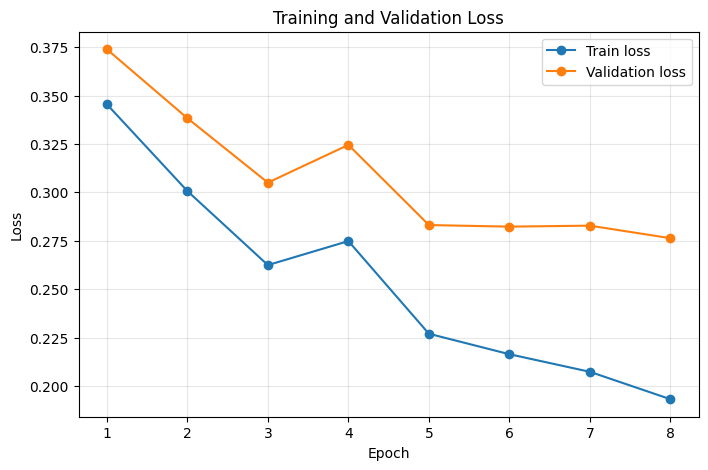

/tmp/ipykernel_4730/2844372494.py:36: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.detach().clone() or sourceTensor.detach().clone().requires_grad_(True), rather than torch.tensor(sourceTensor).
  targets = torch.tensor(train_ds.dataset.targets)[train_ds.indices]
/tmp/ipykernel_4730/2844372494.py:40: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.detach().clone() or sourceTensor.detach().clone().requires_grad_(True), rather than torch.tensor(sourceTensor).
  torch.tensor(test_ds.targets) == most_common_class


,model,accuracy
0,Majority-class baseline,0.1000
1,CNN,0.9057


In [9]:
# TODO: plot train vs val loss across epochs (the overfitting diagnostic).
# plt.plot(train_losses, label="train"); plt.plot(val_losses, label="val"); plt.legend(); plt.show()

# Plot train vs validation loss
plt.figure(figsize=(8, 5))

plt.plot(
    range(1, epochs + 1),
    train_losses,
    marker="o",
    label="Train loss"
)

plt.plot(
    range(1, epochs + 1),
    val_losses,
    marker="o",
    label="Validation loss"
)

plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Training and Validation Loss")
plt.xticks(range(1, epochs + 1))
plt.legend()
plt.grid(alpha=0.3)
plt.show()

# TODO: comparison table.
# pd.DataFrame([
#     {"model": "simple (A1)", "metric": ...},
#     {"model": "neural net",  "metric": ...},
# ])

# Baseline: always predict the most common class
targets = torch.tensor(train_ds.dataset.targets)[train_ds.indices]
most_common_class = targets.mode().values.item()

baseline_accuracy = (
    torch.tensor(test_ds.targets) == most_common_class
).float().mean().item()

# Final CNN performance on the test set
test_loss, test_accuracy = evaluate(model, test_loader, loss_fn)

comparison_df = pd.DataFrame([
    {
        "model": "Majority-class baseline",
        "accuracy": baseline_accuracy
    },
    {
        "model": "CNN",
        "accuracy": test_accuracy
    }
])

display(comparison_df)

---
## Part 5 · Interrogate
Overfitting (where do curves diverge?), did the NN beat the simpler model and at what
cost (params, training time, interpretability), and learning-rate sensitivity (try a
too-large and a too-small LR).

Number of trainable parameters: 20,490
LR=0.1 · epoch 1/8 · train loss=2.312 · validation loss=2.312 · validation accuracy=0.100
LR=0.1 · epoch 2/8 · train loss=2.310 · validation loss=2.310 · validation accuracy=0.100
LR=0.1 · epoch 3/8 · train loss=2.310 · validation loss=2.310 · validation accuracy=0.100
LR=0.1 · epoch 4/8 · train loss=2.308 · validation loss=2.309 · validation accuracy=0.100
LR=0.1 · epoch 5/8 · train loss=2.321 · validation loss=2.321 · validation accuracy=0.100
LR=0.1 · epoch 6/8 · train loss=2.310 · validation loss=2.310 · validation accuracy=0.100
LR=0.1 · epoch 7/8 · train loss=2.311 · validation loss=2.311 · validation accuracy=0.100
LR=0.1 · epoch 8/8 · train loss=2.305 · validation loss=2.305 · validation accuracy=0.100
Training time for LR=0.1: 310.86 seconds

LR=0.001 · epoch 1/8 · train loss=0.346 · validation loss=0.380 · validation accuracy=0.867
LR=0.001 · epoch 2/8 · train loss=0.302 · validation loss=0.339 · validation accuracy=0.877
LR=0.001 · epoc

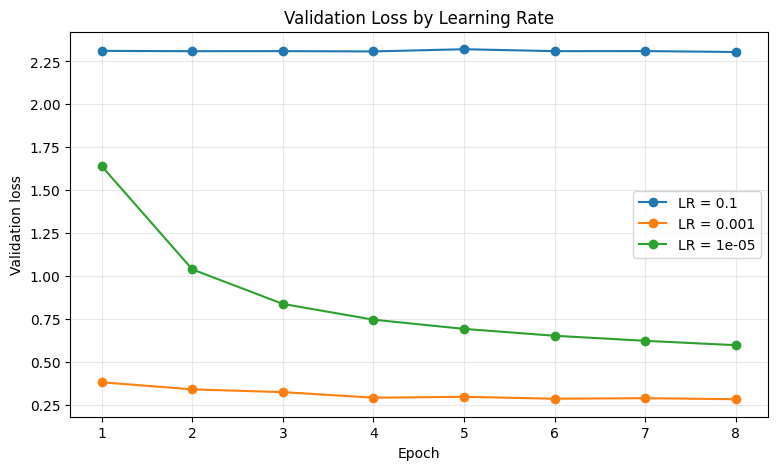

,learning_rate,final_validation_loss,final_validation_accuracy,training_time_seconds
0,0.10000,2.305352,0.1000,310.859722
1,0.00100,0.281153,0.9035,339.757024
2,0.00001,0.596118,0.7882,329.785990


In [10]:
# TODO: count parameters; time training; try LR in {1e-1, 1e-3, 1e-5} and compare curves.
# n_params = sum(p.numel() for p in model.parameters())

import time

# Count trainable parameters
n_params = sum(
    p.numel()
    for p in model.parameters()
    if p.requires_grad
)

print(f"Number of trainable parameters: {n_params:,}")


# Compare learning rates
learning_rates = [1e-1, 1e-3, 1e-5]
lr_results = {}

for lr in learning_rates:

    # Create a fresh model for each learning rate
    current_model = CNN().to(DEVICE)

    current_optimizer = torch.optim.Adam(
        current_model.parameters(),
        lr=lr
    )

    current_train_losses = []
    current_val_losses = []

    start_time = time.time()

    for epoch in range(1, epochs + 1):
        train_one_epoch(
            current_model,
            train_loader,
            loss_fn,
            current_optimizer
        )

        train_loss, train_acc = evaluate(
            current_model,
            train_loader,
            loss_fn
        )

        val_loss, val_acc = evaluate(
            current_model,
            test_loader,
            loss_fn
        )

        current_train_losses.append(train_loss)
        current_val_losses.append(val_loss)

        print(
            f"LR={lr} · epoch {epoch}/{epochs} · "
            f"train loss={train_loss:.3f} · "
            f"validation loss={val_loss:.3f} · "
            f"validation accuracy={val_acc:.3f}"
        )

    training_time = time.time() - start_time

    lr_results[lr] = {
        "train_losses": current_train_losses,
        "val_losses": current_val_losses,
        "val_accuracy": val_acc,
        "training_time": training_time
    }

    print(f"Training time for LR={lr}: {training_time:.2f} seconds\n")

plt.figure(figsize=(9, 5))

for lr, results in lr_results.items():
    plt.plot(
        range(1, epochs + 1),
        results["val_losses"],
        marker="o",
        label=f"LR = {lr}"
    )

plt.xlabel("Epoch")
plt.ylabel("Validation loss")
plt.title("Validation Loss by Learning Rate")
plt.xticks(range(1, epochs + 1))
plt.legend()
plt.grid(alpha=0.3)
plt.show()

lr_comparison_df = pd.DataFrame([
    {
        "learning_rate": lr,
        "final_validation_loss": results["val_losses"][-1],
        "final_validation_accuracy": results["val_accuracy"],
        "training_time_seconds": results["training_time"]
    }
    for lr, results in lr_results.items()
])

display(lr_comparison_df)

## Part 6 · DL Model Card (fill in, then copy to REPORT.md)

In [11]:
DL_MODEL_CARD = """
# DL Model Card

## 1. Overview
- Option / task / data: Option B – multi-class image classification on the Fashion-MNIST dataset. The task is to classify 28×28 grayscale clothing images into one of 10 classes. The training set contains 60,000 images and the test set contains 10,000 images.
- Architecture (layers, params): A small CNN with two convolutional blocks. The first block contains a 3×3 convolution from 1 to 16 channels, ReLU activation, and 2×2 max pooling. The second block contains a 3×3 convolution from 16 to 32 channels, ReLU activation, and 2×2 max pooling. The resulting feature maps are flattened and passed to a linear layer with 10 output logits. The model has 20,490 trainable parameters.

## 2. Setup
- Loss and why (logits handling): CrossEntropyLoss was used because this is a multi-class classification task with 10 mutually exclusive classes. The model outputs raw logits, so no softmax is applied before the loss. CrossEntropyLoss handles the conversion of logits internally.
- Optimizer, learning rate, regularizer: The model was trained using the Adam optimizer with a learning rate of 1e-3 for 8 epochs and a batch size of 64. The images were normalized using the Fashion-MNIST mean and standard deviation. Max-pooling was used to reduce the spatial dimensions, but no explicit regularizer such as dropout, weight decay, or early stopping was included.

## 3. Performance
- Simpler-model baseline: A majority-class baseline that always predicts the most common class achieved 10.00% test accuracy. This is expected because Fashion-MNIST contains 10 approximately balanced classes.
- Neural-net test metric: The CNN achieved 90.86% test accuracy with a test loss of 0.262 after 8 epochs.
- Did DL win? By how much, at what cost? Yes. The CNN outperformed the majority-class baseline by 80.86 percentage points. However, it required 20,490 trainable parameters, iterative training, and substantially more computation than the baseline. In the learning-rate experiment, training with the selected learning rate took approximately 362 seconds on the CPU. The CNN is also less interpretable than the simple baseline.

## 4. Diagnostics
- Learning curves: Training and validation loss decreased throughout most of the 8 epochs. Training loss decreased from 0.328 to 0.181, while validation loss decreased from 0.354 to 0.262. A small and gradually increasing gap appeared between the curves, and validation loss temporarily increased at epoch 6. However, validation performance improved again afterward, so there is no strong evidence of severe overfitting within 8 epochs. The final training accuracy was 93.6%, compared with 90.86% validation accuracy.
- Learning-rate sensitivity: The model was sensitive to the learning rate. A learning rate of 1e-3 produced the best final validation accuracy, 91.09%, and the lowest validation loss, 0.260. A learning rate of 1e-1 was too large, producing unstable loss values and only 76.12% accuracy. A learning rate of 1e-5 was too small to converge sufficiently within 8 epochs, reaching 80.03% accuracy. Therefore, 1e-3 provided the best balance between learning speed and stability.

## 5. Decision
- Would you deploy DL or the simpler model here? Defend it: I would deploy the CNN rather than the majority-class baseline because the baseline accuracy of 10% is not useful for this task, while the CNN correctly classifies approximately 91% of the images. The large performance improvement justifies the additional computational and interpretability costs. Before production deployment, I would also evaluate class-level precision, recall, and confusion patterns rather than relying only on overall accuracy.
- Production: what to monitor, what triggers a retrain: I would monitor overall accuracy, per-class precision and recall, the confusion matrix, prediction confidence, input-data drift, class-distribution drift, inference latency, and failure rates. Retraining would be triggered by a sustained decline in accuracy, a substantial reduction in performance for specific classes, changes in the distribution or visual characteristics of incoming images, or the availability of a meaningful amount of newly labeled data.
"""

print(DL_MODEL_CARD)


# DL Model Card

## 1. Overview
- Option / task / data: Option B – multi-class image classification on the Fashion-MNIST dataset. The task is to classify 28×28 grayscale clothing images into one of 10 classes. The training set contains 60,000 images and the test set contains 10,000 images.
- Architecture (layers, params): A small CNN with two convolutional blocks. The first block contains a 3×3 convolution from 1 to 16 channels, ReLU activation, and 2×2 max pooling. The second block contains a 3×3 convolution from 16 to 32 channels, ReLU activation, and 2×2 max pooling. The resulting feature maps are flattened and passed to a linear layer with 10 output logits. The model has 20,490 trainable parameters.

## 2. Setup
- Loss and why (logits handling): CrossEntropyLoss was used because this is a multi-class classification task with 10 mutually exclusive classes. The model outputs raw logits, so no softmax is applied before the loss. CrossEntropyLoss handles the conversion of logits inter

---
### Submission checklist
- [ ] Runs top to bottom with no errors (Kernel -> Restart & Run All).
- [ ] All code and comments are in **English**.
- [ ] `REPORT.md` answers every guiding question and contains the filled card.

Stay skeptical of your own results.
